In [2]:
import pandas as pd
import numpy as np

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
train = pd.read_pickle(
    "../data/train_feature_engineered.pkl"
)

print(train.shape)

(590540, 432)


In [4]:
y = train["isFraud"]

X = train.drop(
    columns=[
        "isFraud",
        "TransactionID"
    ]
)

In [5]:
categorical_cols = X.select_dtypes(
    include=["object","category"]
).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(
        X[col].astype(str)
    )

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [8]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(
        0.3
    ),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(
        0.3
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=1024
)

Epoch 1/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - AUC: 0.8185 - loss: 0.1212 - val_AUC: 0.8727 - val_loss: 0.0986
Epoch 2/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.8670 - loss: 0.1018 - val_AUC: 0.8850 - val_loss: 0.0956
Epoch 3/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.8766 - loss: 0.0974 - val_AUC: 0.8926 - val_loss: 0.0931
Epoch 4/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.8848 - loss: 0.0936 - val_AUC: 0.8953 - val_loss: 0.0889
Epoch 5/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.8925 - loss: 0.0903 - val_AUC: 0.9041 - val_loss: 0.0861
Epoch 6/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.8983 - loss: 0.0877 - val_AUC: 0.9043 - val_loss: 0.0840
Epoch 7/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.9015 - loss: 0.0857 - val_AUC: 0.9058 - val_loss: 0.0825
Epoch 8/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.9068 - loss: 0.0835 - val_AUC: 0.9126 - val_loss: 0.0830
Epoch 9/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AU

In [11]:
y_proba = model.predict(
    X_test
)

y_pred = (
    y_proba > 0.5
).astype(int)

3691/3691 ━━━━━━━━━━━━━━━━━━━━ 3s 806us/step


In [12]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_proba
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.87      0.44      0.58      4133

    accuracy                           0.98    118108
   macro avg       0.93      0.72      0.79    118108
weighted avg       0.98      0.98      0.97    118108

ROC-AUC: 0.9139485235039988


In [13]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [14]:
epochs=10
batch_size=1024

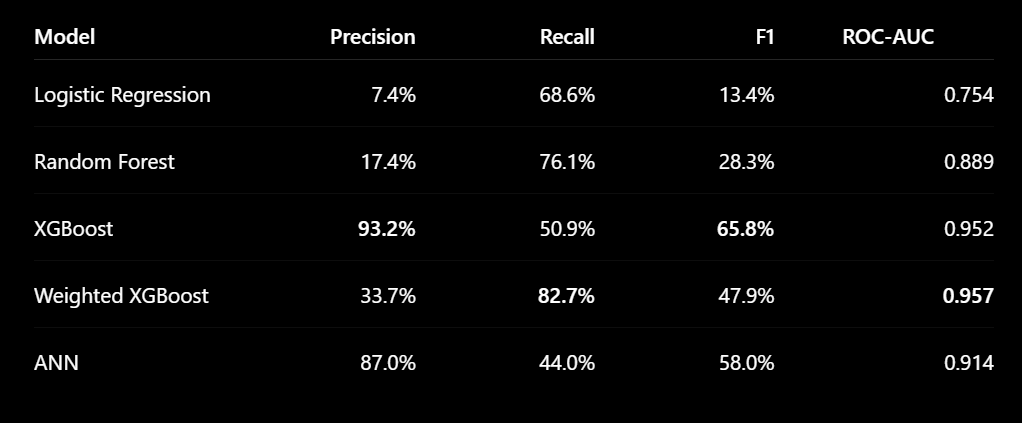

Multiple machine learning and deep learning models were evaluated, including Logistic Regression, Random Forest, XGBoost, Weighted XGBoost, and Artificial Neural Networks. Weighted XGBoost achieved the best balance between fraud detection capability and overall discrimination performance, with a ROC-AUC of 0.957 and recall of 82.7%